# Chapter 5. 모델 평가와 성능 향상
- 분류에서 score 메서드는 정확히 분류된 샘플의 비율을 계산하는 역할을 수행
- 모델이 훈련 세트에 잘 맞는 것보다, **학습 과정에 없던 데이터에 대해 예측을 얼마나 잘 하느냐가 중요**
- 이번 Chapter에서 다루는 내용
> - **안정적인 일반화 성능 측정 방법인 교차 검증**을 소개
> - score 메서드가 제공하는 정확도와 R2 값 이외에 **분류와 회귀 성능을 측정하는 다른 방법**
> - 지도 학습 모델의 **매개변수를 조정하는 데 유용한 그리드 서치**에 관해서도 다룸

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
import IPython
import sklearn
import mglearn

print('Python 버전:', sys.version)
print('numpy 버전:', np.__version__)
print('pandas 버전:', pd.__version__)
print('matplotlib 버전:', matplotlib.__version__)

print('SciFy 버전:', sp.__version__)
print('IPython 버전:', IPython.__version__)
print('scikit-learn 버전:', sklearn.__version__)

from sklearn.model_selection import train_test_split
#plt.rc('font', family="Apple SD Gothic Neo")

Python 버전: 3.11.4 (main, Jul  5 2023, 14:15:25) [GCC 11.2.0]
numpy 버전: 1.24.3
pandas 버전: 1.5.3
matplotlib 버전: 3.7.1
SciFy 버전: 1.10.1
IPython 버전: 8.12.0
scikit-learn 버전: 1.2.2


## 5.3 평가지표와 측정
- 특정 머신러닝 어플리케이션에서 특정 알고리즘을 선택하여 나타난 결과를 **비즈니스 임팩트에 어떻게 연결할 것인가 고민 필요**
- **결과에 대한 비즈니스 해석적인 관점의 코멘트를 기입 할 것**, ex)  고객수는 10% 늘지만 고객당 매출은 15% 감소
- 모델을 선택하고 매개변수를 조정할 때, 비즈니스 지표에 긍정적인 영향을 주는 모델과 매개변수를 선택해야 함

### 5.3.2 이진 분류의 평가 지표
- 이진 분류에는 양성 클래스와 음성 클래스가 있으며, **양성 클래스가 우리의 관심 클래스임**

#### <U>*에러의 종류*</U>
- **거짓 양성(false positive)를 타입 I 에러**
- **거짓 음성(false negative)를 타입 II 에러**
- 일반적으로 거짓 양성의 중요도와 거짓 음성의 중요도가 비슷한 경우가 매우 드묾, 상업적인 어플리케이션에서는 **두 오류를 비용으로 환산하여**, 예측 오류로 인한 금전적 손해를 측정한 값을 **정확도 대신 사용하기도 함**
- ex) 암 진단 예에서는 거짓 음성을 최대한 피해야 하는 반면, 거짓 양성을 비교적 중요도가 낮음

#### <U>*불균형 데이터셋*</U>
- **두 종류의 에러는 두 클래스 중 하나가 다른 것보다 훨씬 많을 때 더 중요함**

> - digits 데이터셋을 사용해 숫자 9를 다른 숫자와 구분해서 9:1의 불균형한 데이터 셋으로 검토
> - 타겟 값이 0-8일 때는 False, 9일 때는 True로 만들어 이진 분류의 문제로 변환

In [3]:
from sklearn.datasets import load_digits
digits = load_digits()
y = digits.target == 9
print('형태:', digits.data.shape, y.shape)
print('값:', digits.target, y)
unique, count = np.unique(y, return_counts=True)
unique, count

형태: (1797, 64) (1797,)
값: [0 1 2 ... 8 9 8] [False False False ... False  True False]


(array([False,  True]), array([1617,  180]))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(digits.data, y, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1347, 64), (450, 64), (1347,), (450,))

> - **항상 다수인 클래스**(여기서는 '9 아님')를 예측값으로 내놓는 **DummyClassifier를 사용해서 정확도 계산**
>> - *DummyClassifier*는 실제 모델과 비교하기 위해 간단한 규칙을 지원하는 모델, 회귀에서는 *DummyRegressor*
>> - (분류)  **strategy 옵션**으로 지정할 수 있는 규칙은 **클래스 레이블 비율에 맞게 예측하는 *stratified*, 가장 많은 레이블을 예측하는 *most_frequent* 등**
>> - (회귀) 평균값을 예측하는 *mean* (기본값)과 중간값을 예측하는 *median* 등이 있음

In [7]:
from sklearn.dummy import DummyClassifier
dummy_majority = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
dummy_stratified = DummyClassifier(strategy='stratified').fit(X_train, y_train)

pred_most_frequent = dummy_majority.predict(X_test)
pred_stratified = dummy_stratified.predict(X_test)

unique_most, count_most = np.unique(pred_most_frequent, return_counts=True)
print('most_frequent 조건:', unique_most, count_most) # X_test가 모두 False로 출력

unique_stratified, count_stratified = np.unique(pred_stratified, return_counts=True)
print('stratified 조건:', unique_stratified, count_stratified) # X_test가 원데이터 비율과 유사하게 출력

most_frequent 조건: [False] [450]
stratified 조건: [False  True] [410  40]


In [9]:
# 각 케이스에서의 테스트 점수
score1 = dummy_majority.score(X_test, y_test)
score2 = dummy_stratified.score(X_test, y_test)

score1, score2

(0.8955555555555555, 0.8155555555555556)

- **거의 아무것도 학습하지 않고(단순 most_frequent한 레이블로 모조리 예측),  90% 가까운 정확도를 보임**
- 원본 훈련셋 클래스 비율대로 무작위로 예측하는 stratified 전략의 더미 분류기도 80%의 정확도를 나타냄
- -> 단순 정확도로 모델 성능을 평가할 수 없는 이유, **불균형 데이터셋에서 예측 성능을 정량화하는데 정확도는 적절한 측정 방법이 아님**

> - 실제 분류기를 사용하여 데이터 학습하여 예측한 결과와 비교

In [11]:
# 의사결정트리 사용 시
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=2).fit(X_train, y_train)
pred_tree = tree.predict(X_test)
score3 = tree.score(X_test, y_test)
score3

0.9177777777777778

In [13]:
# Logistic Regression 사용 시
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(C=0.1, max_iter=1000).fit(X_train, y_train)
pred_logreg = logreg.predict(X_test)
score4 = logreg.score(X_test, y_test)
score4

0.9844444444444445

#### <U>*오차 행렬(confusion matrix)*</U>
- 이진 분류 평가 결과를 나타낼 때 가장 널리 사용하는 방법 중 하나

In [15]:
from sklearn.metrics import confusion_matrix

confusion = confusion_matrix(y_test, pred_logreg)
confusion

array([[402,   1],
       [  6,  41]])

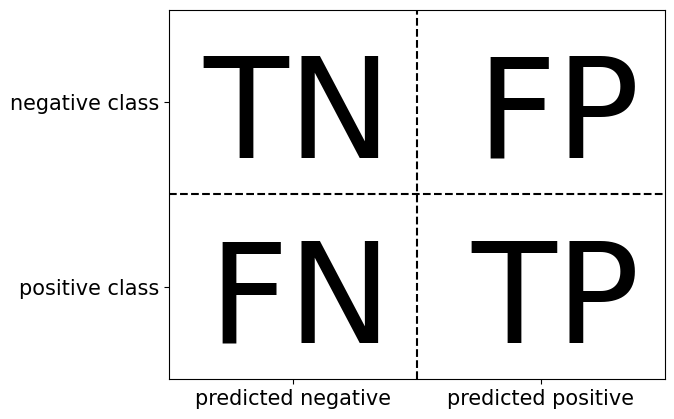

In [17]:
mglearn.plots.plot_binary_confusion_matrix()

> - 오차 행렬을 이용하여 앞서 만든 모델들 (더미 모델 2개, 결정 트리, 로지스틱회귀)을 비교

In [19]:
print('빈도 기반 더미 모델:')
print(confusion_matrix(y_test, pred_most_frequent))

print('\n무작위 더미 모델:')
print(confusion_matrix(y_test, pred_stratified))

print('\n결정 트리:')
print(confusion_matrix(y_test, pred_tree))

print('\n로지스틱 회귀')
print(confusion_matrix(y_test, pred_logreg))
print('\n')

빈도 기반 더미 모델:
[[403   0]
 [ 47   0]]

무작위 더미 모델:
[[367  36]
 [ 43   4]]

결정 트리:
[[390  13]
 [ 24  23]]

로지스틱 회귀
[[402   1]
 [  6  41]]




**결과 해석**
- pred_most_frequent는 모델이 항상 음성(9아님)을 예측
- pred_stratified 모델에서는 거짓 음성(FN)과 거짓 양성(FP) 보다 진짜 양성(TP, 정답 9 맞춤)이 매우 적고(4), 진짜 양성보다 거짓 양성(FP, 9로 예측했는데 9가 아닌 경우)이 매우 많음
- pred_tree(결정 트리의 예측)은 더미 분류기보다 정상으로 보이지만, 정확도는 거의 비슷
- pred_logreg(로지스틱 회귀)는 모든 면에서 pred_tree보다 좋음, 진짜 양성(TP)과 진짜 거짓(TN)이 더 많은 반면, 거짓 양성(FP)과 거짓 음성(FN)은 적음 

> - **ConfusionMatrixDisplay 클래스는 추정기 객체로부터 오차 행렬을 그리는 *from_estimator* 함수와 예측 결과로부터 오차 행렬을 그리는 *from_predictions* 함수를 제공**

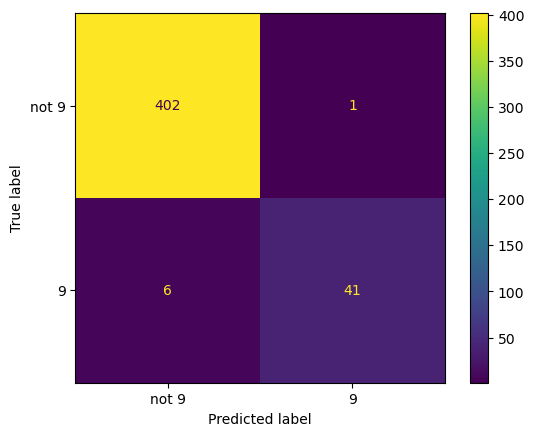

In [21]:
# from_estimator 함수 사용 케이스
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(logreg, X_test, y_test, display_labels=['not 9', '9'])
plt.show()

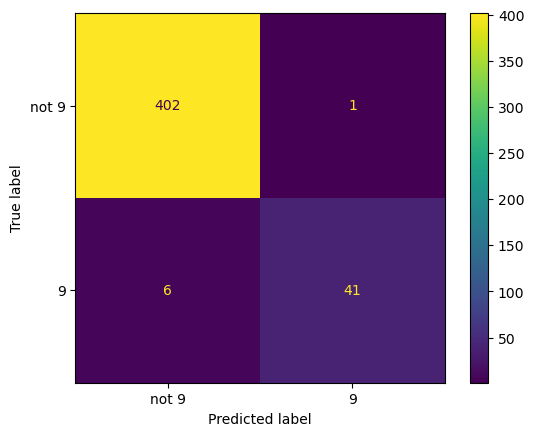

In [23]:
# from_predictions 함수 사용 케이스
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, display_labels=['not 9', '9'])
plt.show()

##### 정확도와의 관계
- 정확도는 정확히 예측한 수 (TP와 TN)을 전체 샘플 수로 나눈 값
$$ 정확도 = {(TP + TN) \over (TP + TN + FP + FN)}$$

##### 정밀도(precision)~ 양성예측도(PPV)
- 모델이 Positive라고 분류한 데이터 중에서 실제로 Positive이 데이터의 비율 (1형 오류 판별)

$$ 정밀도 = {TP  \over (TP + FP )}$$

- **Negative가 중요한 경우 즉, 실제로 Negative인 데이터를 Positive라고 판단하면 안되는 경우 사용되는 지표**
- **= 거짓 양성(FP)의 수를 줄이는 것이 목표일 때 성능 지표로 사용**
- 일반 메일(Nagetive)을 스펨메일(Positive)로 잘못 예측할 경우 문제 발생, 신약 효과 검증시 효과가 없는데(Negative) 있는 것으로 예측(Positive)할 경우 문제 발생(FP)

##### 재현율(recall)~ 민감도, 적중률, 진짜양성비율(TPR)
- 실제로 Positive인 데이터 중에서 모델이 Positive로 분류한 데이터의 비율 (2형 오류 판별)

$$ 재현율 = {TP  \over (TP + FN )}$$

- **Positive가 중요한 경우 즉, 실제로 Positive인 데이터를 Negative라고 판단하면 안되는 경우 사용되는 지표**
- **= 모든 양성 샘플을 식별해야 할 때 성능 지표로 사용, 즉 거짓 음성(FN)을 피하는 것이 중요**
- 악성 종양(Positive)을 양성 종양(Negative)로 잘못 예측할 경우 문제 발생(FN)

##### f-점수
- **재현율 최적화와 정밀도 최적화는 서로 상충함**
> - 모든 데이터를 양성으로 예측하면 진짜 음성(TN)이 거짓 양성(FP)이 되어 정밀도가 떨어지나, 거짓으로 예측한 것이 없으므로 거짓 음성(FN)이 0이 되어 재현율은 1 달성됨
> - 양성 포인트 하나만 예측(예측 적중 시)하면 진짜 양성(TP)은 1, 거짓 양성(FP)는 0이므로 정밀도는 1 달성되나, 나머지 모두를 음성이라고 예측하므로 진짜 음성(TN)을 제외하고 모두 거짓 음성(FN)이므로 재현율이 떨어찜
- **둘 중 하나만으로는 전체 그림을 볼수 없으므로 정밀도와 재현율의 조화 평균인 *f-점수* 로 요약하여 검토 가능함**, 정밀도를 P, 재현율을 R

$$ F = {1 \over {{\alpha \cdot {1\over P}} + {(1-\alpha) \cdot {1\over R}}}} = {(\beta^2+1)PR \over (\beta^2 P+R)},   \beta^2={(1-\alpha)\over \alpha}$$   

 - **F1은 $\beta=1$일 떼, 즉 정밀도와 재현율의 가중치가 동일한 $\alpha=0.5$ 일때 점수를 말하며, $\beta$가 1보다 크면 재현율이 강조되고, 1보다 작으면 정밀도가 강조**

$$ F1 = 2  \times {정밀도 \times 재현율 \over 정밀도 + 재현율 }$$





In [25]:
from sklearn.metrics import f1_score
print('빈도 기반 더미 모델: {:.2f}'.format(f1_score(y_test, pred_most_frequent)))

print('무작위 더미 모델: {:.2f}'.format(f1_score(y_test, pred_stratified)))

print('결정 트리: {:.2f}'.format(f1_score(y_test, pred_tree)))

print('로지스틱 회귀: {:.2f}'.format(f1_score(y_test, pred_logreg)))

빈도 기반 더미 모델: 0.00
무작위 더미 모델: 0.09
결정 트리: 0.55
로지스틱 회귀: 0.92


- 어떤 모델이 좋은지 직관적으로 판단하는 데는 정확도보다 f1 점수가 나음, 그러나 f1 점수는 정확도보다 이해하거나 설명하기 어렵다는 단점 존재

> - ***classification_report* 함수는 정밀도 , 재현율, f1 점수 모두를 한번에 계산해서 출력**
> - classification_report 함수는 클래스마다(여기서는 True, False) 한 줄씩 출력을 만들고 **각 클래스가 양성일 때 정밀도, 재현율, f1 점수를 리포트**

In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_most_frequent, target_names=['9아님','9'], zero_division=0))

              precision    recall  f1-score   support

         9아님       0.90      1.00      0.94       403
           9       0.00      0.00      0.00        47

    accuracy                           0.90       450
   macro avg       0.45      0.50      0.47       450
weighted avg       0.80      0.90      0.85       450



- support => 오른쪽의 마지막 열은 각 클래스에 있는 진짜 샘플의 수
- macro avg => 클래스별 점수의 평균
- weighted avg => 클래스의 샘플 수로 가중 평균
- avg 들은 두 클래스를 평균한 것이므로 양성 클래스의 개념이 필요하지 않음

> - 무작위 더미 분류기와 로지스틱 회귀의 리포트 확인

In [29]:
print(classification_report(y_test, pred_stratified, target_names=['9아님','9'], zero_division=0))

              precision    recall  f1-score   support

         9아님       0.90      0.91      0.90       403
           9       0.10      0.09      0.09        47

    accuracy                           0.82       450
   macro avg       0.50      0.50      0.50       450
weighted avg       0.81      0.82      0.82       450



In [31]:
print(classification_report(y_test, pred_logreg, target_names=['9아님','9'], zero_division=0))

              precision    recall  f1-score   support

         9아님       0.99      1.00      0.99       403
           9       0.98      0.87      0.92        47

    accuracy                           0.98       450
   macro avg       0.98      0.93      0.96       450
weighted avg       0.98      0.98      0.98       450



- **불균형 데이터 이므로 어떤 클래스를 양성 클래스로 선택하느냐가 평가 지표에 큰 영향을 끼침, 더 좋은 성능의 모델을 선택함에 있어 여러 평가지표를 참고해야 함**

##### 기타: FPR (False Positive Ratio)
- **실제로 Negative인 데이터 중에서 모델이 Positive로 분류한 데이터의 비율**

$$ FPR ={FP  \over (FP + TN )}$$

- "비정상 사용자 검출시 FPR이 높다" => 정상 사용자(Negative)를 비정상 사용자(Positive)로 검출하는 경우가 많다

#### <U>*불확실성 고려*</U>
- 예측값은 모델에 담긴 많은 정보가 이미 손실된 상태임
- **분류기는 예측의 확신을 가늠하기 위한 decision_function이나 predict_proba 메서드를 제공**
- **예측을 만들어내는 것은 deecision_function이나 predict_proba 출력의 임계값을 검증하는 것**, 이진 탐색에서 **decision_function은 0**을, **predict_proba는 0.5를 임계값으로 사용**

> - 400개의 음성 클래스, 50개의 양성 클래스로 이루어진 불균형한 이진 분류 문제 -> SVM으로 학습하여 **결정 함수 살펴보기**
> - 아래 오른쪽 결정 함수 히트맵에서 중앙 윗부분에 있는 검은 원은 decision_function이 정확히 0일 때의 임계점을 나타냄

In [33]:
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
X, y = make_blobs(n_samples=(400,50), cluster_std=[7.0,2], random_state=22)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
svc = SVC(gamma=0.05).fit(X_train, y_train)

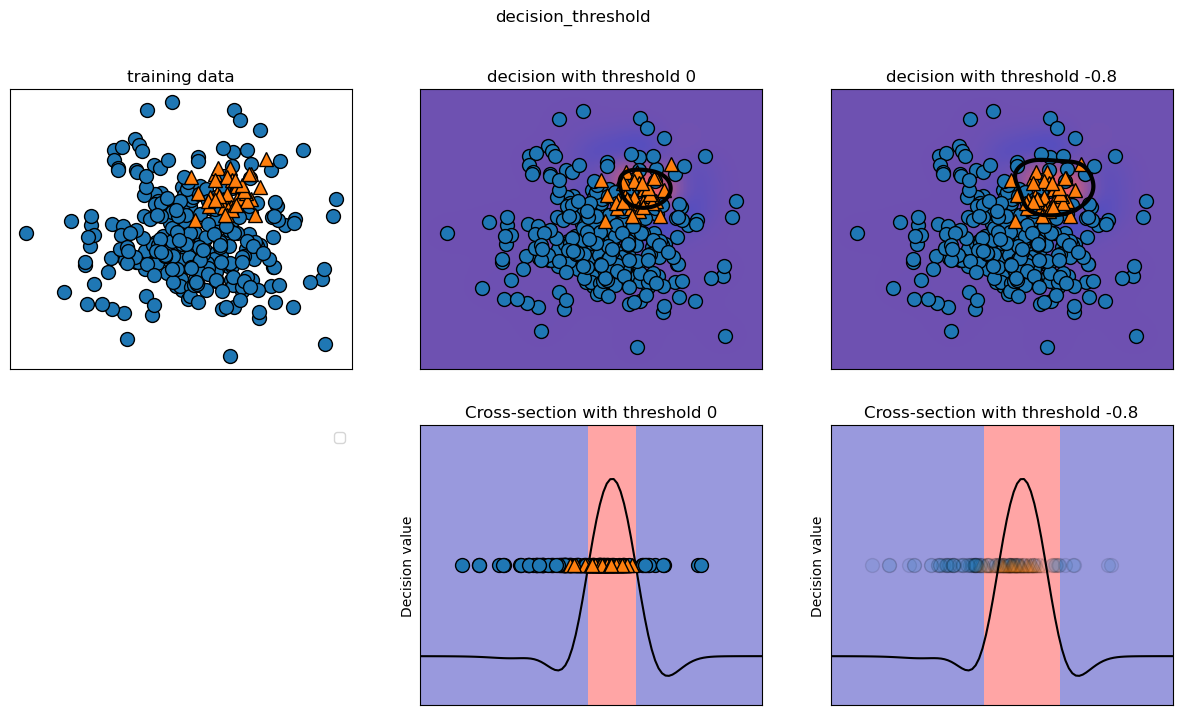

In [34]:
mglearn.plots.plot_decision_threshold()

In [37]:
# classification_report 함수를 사용해 두 클래스의 정밀도와 재현율을 평가
print(classification_report(y_test, svc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93       104
           1       0.35      0.67      0.46         9

    accuracy                           0.88       113
   macro avg       0.66      0.78      0.70       113
weighted avg       0.92      0.88      0.89       113



- 클래스 0(음성)의 샘플이 매우 많으므로 분류기는 소수인 클래스 1(양성)보다 클래스 0에 초점을 맞춤 -> 클래스 1에 대한 정밀도나 재현율이 떨어짐
- 만약 암 진단과 같이 **양성(암)의 재현율을 높이는게 중요**하다면 -> **양성(암)으로 잘못 분류된(FP)이 늘어나더라도 (재현율을 높이기 위해) 진짜 양성(TP)을 늘려야함**
- **-> 임계값을 바꿔 클래스 1의 재현율을 높이도록 예측을 조정할 수 있음**

> - 기본적으로 decision_function의 값이 0보다 큰 포인트는 클래스 1로 분류, 그러므로 **더 많은 포인트가 클래스 1로 분류되려면 임계값을 낮춰야 함**

In [41]:
y_pred_lower_threshold = svc.decision_function(X_test) > -.8

In [43]:
print(classification_report(y_test, y_pred_lower_threshold))

              precision    recall  f1-score   support

           0       1.00      0.82      0.90       104
           1       0.32      1.00      0.49         9

    accuracy                           0.83       113
   macro avg       0.66      0.91      0.69       113
weighted avg       0.95      0.83      0.87       113



- 기대한 대로 클래스 1의 재현율이 높아졌고 정밀도는 낮아짐
- decision_function은 임의의 범위를 가지고 있으므로 **임계점을 고르는 일반적인 방법을 제시하기는 어려움**
- **임계값을 선택할 때 테스트 세트를 사용하지 않도록 주의를 기울여야함**, 위 예제에서는 테스트 세트의 결과를 바탕으로 결정했으나, 실전에서는 검증 세트나 교차검증 사용 권고 

##### predict_proba
- **predict_proba 메서드는 출력이 0에서 1 사이로 고정**되니 predict_proba를 제공하는 모델은 임계값을 선택하기가 더 수월함
- **기본값인 0.5를 임계값으로 설정한 모델은 양성 클래스라는 확신이 50% 이상일 때 양성으로 분류**
- 임계값을 높이면 양성 클래스로 분류할 때 더 큰 확신이 필요 -> 음성 클래스는 확신이 덜 필요
- 임의의 임계값보다는 확률(predict_proba)을 사용하는 쪽이 더 직관적이지만, 모든 모델이 쓸모있는 불확실성을 제공하는 것은 아님,  ex) 최대 깊이까지 자란 DecisionTree는 비록 잘못된 것이라도 항상 100% 확신함
- 보정(calibration) 모델은 불확실성을 정확하게 측정하는 모델로 알렉산드루 니쿨레스쿠-미질과 리치 카루아나가 쓴 Predicting Good Probabilities with Supervised Learning을 참고

#### <U>*정밀도-재현율 곡선과 ROC 곡선*</U>
- 임계값을 바꾸는 것은 해당 분류기의 **정밀도와 재현율의 상충 관계를 조정하는 일**
- 특정 목적을 충족하는 임계값을 설정하는 것은 쉬우나, 어려운 부분은 정밀도와 재현율의 밸런스를 조절하는 것임
- 예를 들어 90% 재현율처럼 분류기의 필요조건을 지정하는 것을 운영 포인트(operation point)를 지정한다고 말함
> - 새로운 모델 생성 시 운영 포인트가 명확하지 않은 경우가 많음
> - **모든 임계값을 조사해보거나, 한 번에 정밀도나 재현율의 모든 장단점을 살펴보는 것이 좋음**
> => 이를 위해 sklearn.metrics 모듈에서 **정밀도 - 재현율 곡선(precision-recall curve)를 만드는 함수를 제공함**
> - 위 함수는 타깃 레이블과 decision_function이나 predict_proba 메서드로 계산한 예측 불확실성을 이용

In [45]:
from sklearn.metrics import precision_recall_curve

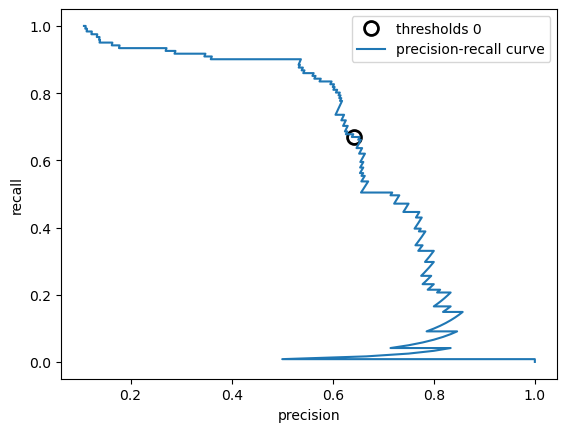

In [46]:
# 부드러운 곡선을 위해 데이터 포인트를 늘림
X, y = make_blobs(n_samples=(4000,500), cluster_std=[7.0, 2], random_state=22)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

svc = SVC(gamma=0.05).fit(X_train, y_train)

precision, recall, thresholds = precision_recall_curve(y_test, svc.decision_function(X_test))

# 0에 가까운 임계값을 찾음
close_zero = np.argmin(np.abs(thresholds))

plt.plot(precision[close_zero], recall[close_zero], 'o', markersize=10, label='thresholds 0', fillstyle='none', c='k', mew=2)
plt.plot(precision, recall, label='precision-recall curve')
plt.xlabel('precision')
plt.ylabel('recall')
plt.legend(loc='best')

> - 분류기가 다르면 곡선의 다른 부분에서 장점이 발생
> - **RandomForestClassifier는 decision_function을 제공하지 않고 predict_proba만 가지고 있음**
> - 정밀도-재현율 곡선 함수는 양성 클래스(클래스 1)의 확신에 대한 측정값을 두번째 매개변수로 받음 => rf.predict_proba(X_test)[ :, 1]을 넘김

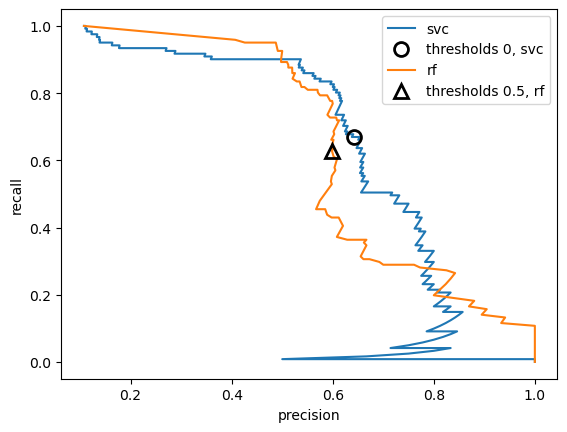

In [50]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=0, max_features=2)
rf.fit(X_train, y_train)

# RandomForestClassifier는 decision_function 대신 predict_proba를 제공
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, rf.predict_proba(X_test)[:,1])

plt.plot(precision, recall, label='svc')
plt.plot(precision[close_zero], recall[close_zero], 'o', markersize=10, label='thresholds 0, svc', fillstyle='none', c='k', mew=2)

plt.plot(precision_rf, recall_rf, label='rf')
close_default_rf = np.argmin(np.abs(thresholds_rf - 0.5))
plt.plot(precision_rf[close_default_rf], recall_rf[close_default_rf], '^', markersize=10, label='thresholds 0.5, rf', fillstyle='none', c='k', mew=2)

plt.xlabel('precision')
plt.ylabel('recall')
plt.legend(loc='best')

- 극단적인 부분, 즉 재현율이 매우 높거나 정밀도가 매우 높을 때는 랜덤 포레스트가 더 낫다는 것을 알 수 있음

> - **f1 점수는 정밀도-재현율 곡선의 한 지점인 기본 임계값에 대한 점수**이므로, f1 점수만으로 전체 성능을 비교하는 것에는 주의가 필요함
> - 모델을 자동으로 비교하려면 특정 임계값이나 운영 포인트에 국한하지 않고 **전체 곡선에 담긴 정보**를 요약해야함
>> **정밀도-재현율 곡선의 아랫부분 면적을 계산한 평균 정밀도(average_precision_score 함수)**
>> 정밀도-재현율 곡선을 계산하고 여러 임계값을 고려해야 하므로, **predict 함수가 아니라 decision_function이나 predict_proba 함수의 결과값을 average_precision_score 함수로 전달**해야함

In [54]:
print('랜덤 포레스트의 f1_score: {:.3f}'.format(f1_score(y_test, rf.predict(X_test))))
print('SVC의 f1_score: {:.3f}'.format(f1_score(y_test, svc.predict(X_test))))

랜덤 포레스트의 f1_score: 0.610
SVC의 f1_score: 0.656


In [56]:
from sklearn.metrics import average_precision_score
ap_rf = average_precision_score(y_test, rf.predict_proba(X_test)[:,1])
ap_svc = average_precision_score(y_test, svc.decision_function(X_test))

print('랜덤 포레스트의 평균 정밀도: {:.3f}'.format(ap_rf))
print('SVC의 평균 정밀도: {:.3f}'.format(ap_svc))

랜덤 포레스트의 평균 정밀도: 0.660
SVC의 평균 정밀도: 0.666


> **scikit-learn 1.2 버전부터 정밀도-재현율 곡선을 그리는 PrecisionRecallDisplay 클래스 사용 가능**
>> - 추정기 객체를 사용한 from_estimator 함수와 예측 결과를 사용하는 from_predictions 함수를 제공

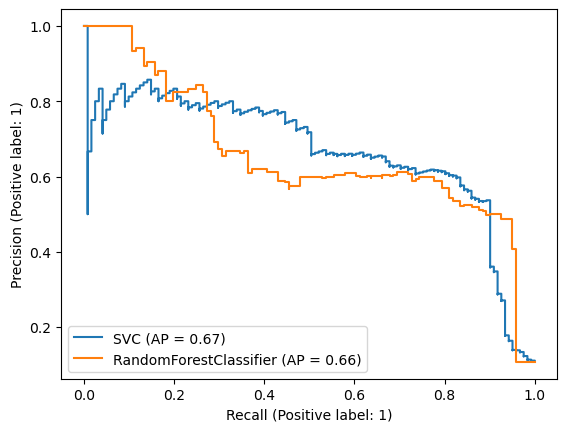

In [59]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots()
PrecisionRecallDisplay.from_estimator(svc, X_test, y_test, ax=ax)
PrecisionRecallDisplay.from_estimator(rf, X_test, y_test, ax=ax)

> - 기존 그래프처럼 정밀도를 x 축, 재현율을 y 축에 놓으려면 PrecisionRecallDisplay 클래스에 정밀도와 재현율을 직접 전달해야함
> - **기본적으로 x 축 이름을 Recall, y축 이름을 Precision으로 설정하기 때문에 축 이름을 수동으로 설정해야함**

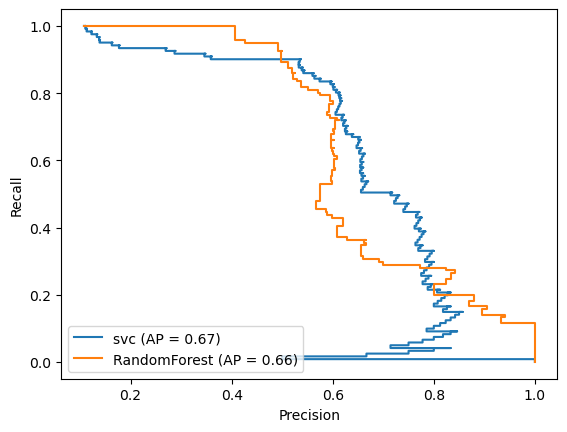

In [62]:
fig, ax = plt.subplots()
disp = PrecisionRecallDisplay(precision=recall, recall=precision, average_precision=ap_svc, estimator_name='svc')
disp.plot(ax=ax)

disp = PrecisionRecallDisplay(precision=recall_rf, recall=precision_rf, average_precision=ap_rf, estimator_name='RandomForest')
disp.plot(ax=ax)
ax.set(xlabel='Precision', ylabel='Recall')
plt.show()

#### <U>*ROC와 AUC*</U>
- **ROC 곡선은 분류기의 모든 임계값을 고려하지만, 정밀도와 재현율 대신 진짜 양성 비율(TPR)에 대한 거짓 양성 비율(FPR)을 나타냄**
- 진짜 양성 비율은 재현율의 다른 이름이며, **거짓 양성 비율은 전체 음성 샘플 중에서 거짓 양성으로 잘못 분류한 비율**
- **ROC 곡선은 *roc_curve* 함수를 사용하여 만들 수 있음**

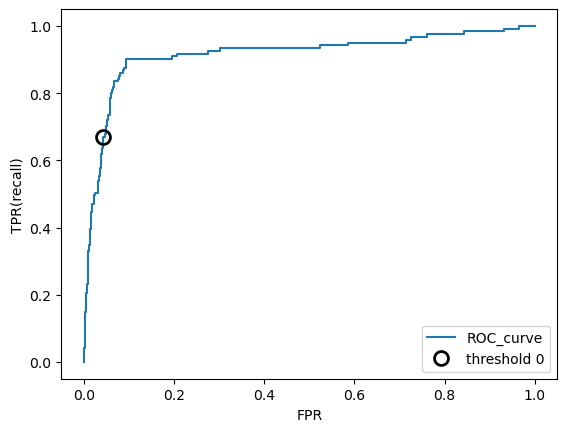

In [65]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, svc.decision_function(X_test))

plt.plot(fpr, tpr, label='ROC_curve')
plt.xlabel('FPR')
plt.ylabel('TPR(recall)')

# 0 근처의 임계값을 찾음
close_zero = np.argmin(np.abs(thresholds))
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10, label='threshold 0', fillstyle='none', c='k', mew=2)
plt.legend(loc=4)

- **왼쪽 상단으로 커브가 당겨 질수록 즉, 커브 아래쪽 면적(AUC)이 증가할수록 모델 성능 향상**
- 임계값을 고르기 위해 테스트 세트를 사용해서는 안 되고 별도의 검증 세트를 활용해야 함

> - 랜덤 포레스트와 SVM의 ROC 곡선을 비교

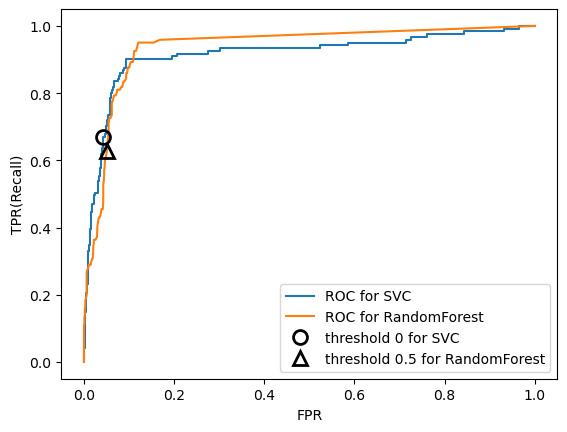

In [69]:
from sklearn.metrics import roc_curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf.predict_proba(X_test)[:,1])

plt.plot(fpr, tpr, label='ROC for SVC')
plt.plot(fpr_rf, tpr_rf, label='ROC for RandomForest')

plt.xlabel('FPR')
plt.ylabel('TPR(Recall)')
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10, label='threshold 0 for SVC', fillstyle='none', c='k', mew=2)

close_default_rf = np.argmin(np.abs(thresholds_rf - 0.5))
plt.plot(fpr_rf[close_default_rf], tpr_rf[close_default_rf], '^', markersize=10, label='threshold 0.5 for RandomForest', fillstyle='none', c='k', mew=2)

plt.legend(loc=4)

> - **정밀도-재현율 곡선에서처럼 곡선 아래의 면적값 하나로 각 임계값에 대한 결과를 하나로 요약할 수 있음, 이것을 AUC(area under the curve)라고 함**
> - ***roc_auc_score* 함수를 사용**
> - 데이터셋에 담긴 클래스가 아무리 **불균형하더라도 무작위로 예측한 AUC 값은0.5(최하성능)가 됨, 그래서 불균형한 데이터셋에서는 정확도보다 AUC가 훨씬 좋은 지표임**
>> - **FPR과 TPR은 오차 행렬에서 각각 다른 행을 이용하여 만들기 때문에** 클래스 불균형이 FPR과 TPR 계산에 영향을 주지 않음
>> - **무작위로 분류하면 클래스별 양성과 음성 비율이 비슷해서 FPR과 TPR 값이 거의 같아 지므로, ROC 곡선은 y=x에 가깝게 되어 AUC 면적은 0.5가 됨**
>> - AUC 값이 기본 임계값과는 상관 없으므로(모든 임계값에 대한 요약), AUC가 높은 모델에서 좋은 분류 결과를 얻으려면 결정 임계값을 조정하여 모델 생성 필요

In [72]:
from sklearn.metrics import roc_auc_score
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
svc_auc = roc_auc_score(y_test, svc.decision_function(X_test))

print('랜덤포레스트의 AUC: {:.3f}'.format(rf_auc))
print('SVC의 AUC: {:.3f}'.format(svc_auc))

랜덤포레스트의 AUC: 0.937
SVC의 AUC: 0.916


> **scikit-learn 1.2 버전부터 ROC 곡선을 그리는 RocCurveDisplay 클래스 사용 가능**
>> - 추정기 객체를 사용한 from_estimator 함수와 예측 결과를 사용하는 from_predictions 함수를 제공

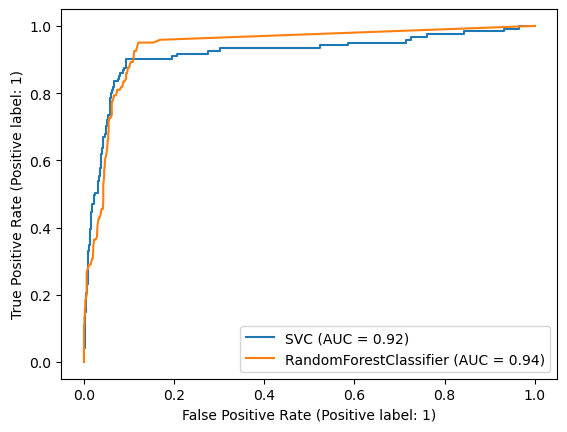

In [75]:
from sklearn.metrics import RocCurveDisplay

# from_estimator 사용 케이스 -> 훈련한 추정기와 특성 데이터(X_test), 타겟 데이터(y_test) 전달
fig, ax= plt.subplots()
# SVC
RocCurveDisplay.from_estimator(svc, X_test, y_test, ax=ax)
# RandomForest
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax)
plt.show()

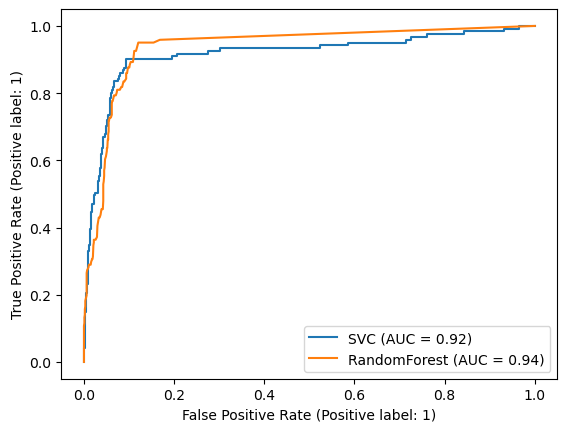

In [77]:
from sklearn.metrics import RocCurveDisplay

# from_predictions 사용 케이스 -> 타겟 데이터(y_test)와 추정기의 decision_function or predict_proba 메서드의 반환값 전달
fig, ax= plt.subplots()
# SVC
RocCurveDisplay.from_predictions(y_test, svc.decision_function(X_test), name='SVC', ax=ax)
# RandomForest
RocCurveDisplay.from_predictions(y_test, rf.predict_proba(X_test)[:,1], name='RandomForest', ax=ax)
plt.show()

### 5.3.3 다중 분류의 평가 지표
- 기본적으로 다중 분류를 위한 지표는 모두 이진 분류 평가지표에서 유도되었으며, **다만 모든 클래스에 대해 평균을 낸 것임**
- 다중 분류의 평가에는 정확도 외에 앞 절의 **오차 행렬과 분류 리포트 등을 일반적으로 사용**

> - 오차 행렬과 분류 리포트를 활용하여 10개 손글씨 숫자를 분류하는데 적용 

In [81]:
from sklearn.metrics import accuracy_score
X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, random_state=0)

lr = LogisticRegression(max_iter=5000).fit(X_train, y_train)
pred = lr.predict(X_test)
print('정확도: {:.3f}'.format(accuracy_score(y_test, pred)))
print('오차 행렬:\n', confusion_matrix(y_test, pred))

정확도: 0.953
오차 행렬:
 [[37  0  0  0  0  0  0  0  0  0]
 [ 0 40  0  0  0  0  0  0  2  1]
 [ 0  0 41  3  0  0  0  0  0  0]
 [ 0  0  0 44  0  0  0  0  1  0]
 [ 0  0  0  0 37  0  0  1  0  0]
 [ 0  0  0  0  0 46  0  0  0  2]
 [ 0  1  0  0  0  0 51  0  0  0]
 [ 0  0  0  1  1  0  0 46  0  0]
 [ 0  3  1  0  0  0  1  0 43  0]
 [ 0  0  0  0  0  1  0  0  2 44]]


- 이진 분류에서처럼 각 행은 정답 레이블에 해당, 열은 예측 레이블에 해당

> - 사이킷런 0.22 버전에서 오차 행렬을 그래프로 그려주는 함수가 추가

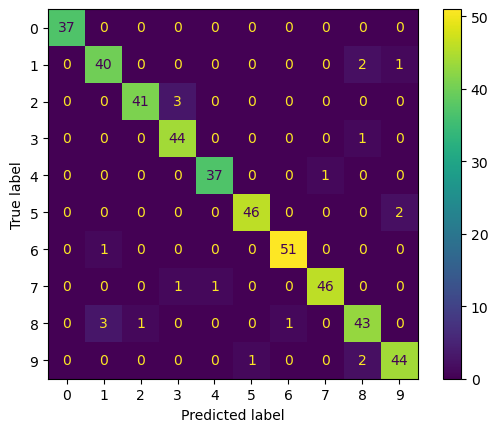

In [85]:
# case1: ConfusionMatrixDisplay + from_estimator 함수 사용 케이스
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.show()

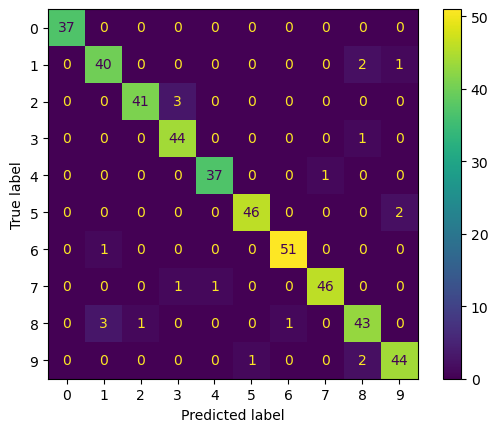

In [87]:
# case2: ConfusionMatrixDisplay + from_predictions 함수 사용 케이스
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.show()

> - classification_report 함수를 사용해서 정밀도, 재현율, f1-점수를 계산

In [90]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       0.91      0.93      0.92        43
           2       0.98      0.93      0.95        44
           3       0.92      0.98      0.95        45
           4       0.97      0.97      0.97        38
           5       0.98      0.96      0.97        48
           6       0.98      0.98      0.98        52
           7       0.98      0.96      0.97        48
           8       0.90      0.90      0.90        48
           9       0.94      0.94      0.94        47

    accuracy                           0.95       450
   macro avg       0.95      0.95      0.95       450
weighted avg       0.95      0.95      0.95       450



- **다중 분류에서 불균형 데이터셋을 위해 가장 널리 사용하는 평가 지표는 f1-점수의 다중 분류 버전**
- 다중 클래스용 f1-점수는 한 클래스를 양성 클래스로 두고 나머지 클래스들을 음성 클래스로 간주하여 클래스 마다 f1-점수를 계산
- 클래스별 f1-점수를 다음 전략 중 하나를 사용하여 평균을 구함
> - ***"macro" 평균* : 클래스별 f1-점수에 가중치를 주지 않음**, 클래스 크기에 상관 없이 모든 클래스를 같은 비중으로 다룸
> - ***"weighted" 평균* : 클래스별 샘플 수로 가중치를 두어 f1-점수의 평균을 계산**
> - ***"micro" 평균* : 모든 클래스의 거짓양성(FP), 거짓음성(FN), 진짜양성(TP)의 총 수를 헤아린 다음 계산** => precision, recall, f1 점수 모두 동일, 위 report에서 **micro avg가 아닌 accuracy 하나의 값만 표현**  (https://data-minggeul.tistory.com/11)
> - 모든 라벨이 유사한 중요도를 가진다면 macro 참고, 샘플이 많은 라벨에 중요도를 두고 싶으면 weighted 참고, 그리고 라벨에 상관 없이 전체 성능을 평가하고 싶을 때는 micro (accuracy) 참고

In [93]:
print('micro 평균 f1 점수: {:.3f}'.format(f1_score(y_test, pred, average='micro')))
print('macro 평균 f1 점수: {:.3f}'.format(f1_score(y_test, pred, average='macro')))

micro 평균 f1 점수: 0.953
macro 평균 f1 점수: 0.954


### 5.3.4 회귀의 평가 지표
- **대부분의 애플리케이션에서는 회귀 추정기의 score 메서드에서 이용하는 R2만으로 충분**
- 가끔 평균 제곱 에러(MSE)나 평균 절대값 에러(MAE)를 사용하나, 일반적으로 R2이 더 나은 지표

### 5.3.5 모델 선택에서 평가 지표 사용하기
- GridSearchCV나 cross_val_score를 사용하여 모델을 선택할 때, ***scoring* 매개변수를 통해 기본값(정확도)외 평균 정밀도나 AUC 같은 평가지표 사용 가능**
> - digits 데이터셋을 가지고 '9와 9 아님'을 분류하는 SVM 모델을 평균 정밀도 점수로 평가

In [97]:
from sklearn.model_selection import cross_val_score
# 분류의 기본 평가 지표는 정확도임
print('기본 평가 지표:',
      cross_val_score(SVC(), digits.data, digits.target==9, cv=5))

# scoring='accuracy'의 결과
explicit_accuracy = cross_val_score(SVC(), digits.data, digits.target==9, cv=5, scoring='accuracy')
print('정확도 지표:', explicit_accuracy)

# scoring='roc_auc'의 결과
roc_auc = cross_val_score(SVC(), digits.data, digits.target==9, cv=5, scoring='roc_auc')
print('AUC 지표:', roc_auc)

# scoring='average_precision'의 결과, 평균 정밀도 = 정밀도-재현율 곡선의 아랫부분 면적
ap = cross_val_score(SVC(), digits.data, digits.target==9, cv=5, scoring='average_precision')
print('평균 정밀도 지표:', ap)
      

기본 평가 지표: [0.975      0.99166667 1.         0.99442897 0.98050139]
정확도 지표: [0.975      0.99166667 1.         0.99442897 0.98050139]
AUC 지표: [0.99717078 0.99854252 1.         0.999828   0.98400413]
평균 정밀도 지표: [0.97562403 0.9886322  1.         0.99853801 0.95015534]


> - **cross_validate, GridSearchCV 함수는 *scoring* 매개변수에 여러 개의 측정 지표를 지정하여 탐색 가능함**

In [100]:
from sklearn.model_selection import cross_validate
res = cross_validate(SVC(), digits.data, digits.target==9,
                     scoring=['accuracy','roc_auc', 'recall_macro'],
                     return_train_score=True, cv=5)
pd.DataFrame(res)

,fit_time,score_time,test_accuracy,train_accuracy,test_roc_auc,train_roc_auc,test_recall_macro,train_recall_macro
0,0.018368,0.014612,0.975000,0.994433,0.997171,0.998679,0.887346,0.972222
1,0.017014,0.013463,0.991667,0.995825,0.998543,0.999141,0.958333,0.982252
2,0.020003,0.014236,1.000000,0.995132,1.000000,0.998975,1.000000,0.978780
3,0.026171,0.023279,0.994429,0.995828,0.999828,0.998825,0.972222,0.982252
4,0.019710,0.013550,0.980501,0.996523,0.984004,0.999914,0.902778,0.985725


In [118]:
# GridSearchCV 사용, 정확도 지표 사용
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target==9, random_state=0)

# 일부러 적절하지 않은 그리드를 생성
param_grid = {'gamma': [0.0001, 0.01, 0.1, 1, 10]}
# 기본 정확도 측정 지표를 사용
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=3)
grid.fit(X_train, y_train)
print('정확도 지표를 사용한 그리드서치')
print('최적의 파라미터', grid.best_params_)
print('최상의 교차 검증 점수(정확도): {:.3f}'.format(grid.best_score_))
print('테스트 세트 평균 정밀도: {:.3f}'.format(average_precision_score(y_test, grid.decision_function(X_test))))
print('테스트 세트 정확도: {:.3f}'.format(grid.score(X_test, y_test)))

정확도 지표를 사용한 그리드서치
최적의 파라미터 {'gamma': 0.0001}
최상의 교차 검증 점수(정확도): 0.972
테스트 세트 평균 정밀도: 0.966
테스트 세트 정확도: 0.973


In [120]:
# GridSearchCV 사용, 평균 정밀도 지표 사용
grid = GridSearchCV(SVC(), param_grid=param_grid, scoring='average_precision', cv=3)
grid.fit(X_train, y_train)
print('평균 정밀도를 사용한 그리드서치')
print('최적의 파라미터', grid.best_params_)
print('최상의 교차 검증 점수(평균 정밀도): {:.3f}'.format(grid.best_score_))
print('테스트 세트 평균 정밀도: {:.3f}'.format(average_precision_score(y_test, grid.decision_function(X_test))))
print('테스트 세트 정확도: {:.3f}'.format(grid.score(X_test, y_test)))

평균 정밀도를 사용한 그리드서치
최적의 파라미터 {'gamma': 0.01}
최상의 교차 검증 점수(평균 정밀도): 0.985
테스트 세트 평균 정밀도: 0.996
테스트 세트 정확도: 0.996


- **분류 문제**에서 *scoring* 매개변수의 중요한 옵션은 ***accuracy***(기본값), ROC 곡선의 아래 면적인 ***roc_auc***, 정확도-재현율 곡선의 아래 면적인 ***average_precision***, 이진 f1-점수인 f1과 다중 분류에서는 가중치 방식에 따라 ***f1_macro, f1_micro, f1_weighted***가 있음
- **회귀**에서 가장 널리 사용하는 것은 ***r2***, 평균 제곱 오차인 ***neg_mean_squared_error***, 평균 절대값 오차인 ***neg_mean_absolute_error***임

## 5.4 요약 및 정리
- **모델 학습에는 훈련 데이터로, 모델과 매개변수 선택에는 검증 데이터로, 모델 평가에는 테스트 데이터로 분리해서 사용해야함**
> - 이때, 간단하게 한번만 분리하는 대신 **교차 검증으로 분할을 반복**
> - 가장 널리 사용하는 구성은 훈련 세트와 테스트 세트로 분할하고 모델과 모델 매개변수 선택을 위해 훈련 세트에 교차 검증을 적용
- 머신 러닝 모델의 예측으로부터 비즈니스 결정을 내리는 이론 -> **포스터 프로보스트 "비지니스를 위한 데이터 과학"**(https://product.kyobobook.co.kr/detail/S000001057534)